## Before running this notebook:
If you don't have Xolotl installed yet, refer to https://github.com/ORNL-Fusion/xolotl/wiki/Build-Configuration#quick-start
<br>
<br>
Copy the parameter file ```param_dummy_NE_1.json``` and data file ```reaction_system_NE_0.dat``` (from ./xolotl-source/tutorial/inputs/) in your build folder.
<br>
<br>
(Serial) Run the following command in your terminal within the build directory:


```bash
./xolotl param_dummy_NE_1.json
```
This simulation is 0D, so no MPI tasks should be used. 

For more information on running Xolotl, see the wiki: https://github.com/ORNL-Fusion/xolotl/wiki/Running-Xolotl

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
from   pylab import *
import h5py
from matplotlib.colors import LogNorm


Modules to load. Most important for extracting data from xolotl is h5py

In [2]:

name = ['xolotlStop.h5', 'xolotlStop.h5', 'xolotlStop.h5', 'xolotlStop.h5']
#timestep = [694, 741, 819, 893]
timestep = [694, 735, 822, 899]
col = ['black', 'blue', 'magenta', 'green']
lab = ['1e6 s', '3e6 s', '7e6 s', '1e7 s']

with h5py.File(name[0], "r") as f:
    print(list(f["concentrationsGroup"].keys()))

['concentration_0_0_0', 'concentration_0_0_694', 'concentration_0_0_711', 'concentration_0_0_735', 'concentration_0_0_759', 'concentration_0_0_776', 'concentration_0_0_802', 'concentration_0_0_822', 'concentration_0_0_861', 'concentration_0_0_877', 'concentration_0_0_899']


Create lists of file names to read from, time step number in the file, associated line colors, labels

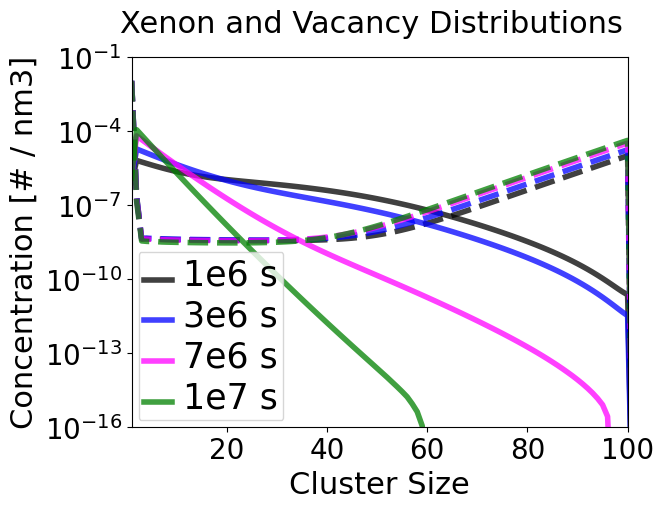

In [3]:
## Set the Zero
zero = 1.0e-20

## Set the maximum size of xenon
maxSize = 1000001
## Create plots
fig = plt.figure()
title = 'Xenon and Vacancy Distributions'
fig.suptitle(title,fontsize=22)
xePlot = plt.subplot(111)

for i in range(len(name)):
    ## Open the file
    f = h5py.File(name[i], 'r')

    ## Open the concentration group
    groupName ='concentrationsGroup/concentration_0_0_' + str(timestep[i])
    concGroup = f[groupName]

    ## Read the concentration and index datasets
    concDset = concGroup['concs']
    indexDset = concGroup['concs_startingIndices']

    ## Read the time at the chosen time step
    time = concGroup.attrs['absoluteTime']

    ## Read how many normal and super clusters there are
    networkGroup = f['networkGroup']
    totalSize = networkGroup.attrs['totalSize']

    ## Create the mesh and data array
    x = np.empty([maxSize])
    xeArray = np.empty([maxSize])
    vArray = np.empty([maxSize])
    for j in range(maxSize):
        x[j] = j
        xeArray[j] = zero
        vArray[j] = zero
    
    pos = 0 ## if 0D
    for j in range(indexDset[pos], indexDset[pos+1]):
        ## Skip the moments for now
        if (int(concDset[j][0]) > totalSize - 1): continue
        ## Get the cluster bounds
        groupName = str(concDset[j][0])
        clusterGroup = networkGroup[groupName]
        bounds = clusterGroup.attrs['bounds']
        ## Loop on Xe size
        for l in range(bounds[0], bounds[1]+1):
            ## Fill the array
            xeArray[l] = xeArray[l] + concDset[j][1]
        ## Loop on V size
        for l in range(bounds[2], bounds[3]+1):
            ## Fill the array
            vArray[l] = vArray[l] + concDset[j][1]

    ## Plot the data
    x = np.delete(x,(0), axis=0)
    xeArray = np.delete(xeArray,(0), axis=0)
    vArray = np.delete(vArray,(0), axis=0)
    xePlot.plot(x, xeArray, lw=4, color=col[i], label=lab[i], alpha=0.75)
    xePlot.plot(x, vArray, lw=4, color=col[i], alpha=0.75, ls='--')

## Some formatting
xePlot.set_xlabel("Cluster Size",fontsize=22)
xePlot.set_ylabel("Concentration [# / nm3]",fontsize=22)
xePlot.set_xlim([1, 100])
xePlot.set_ylim([1.0e-16, 1.0e-1])
#xePlot.set_xscale('log')
xePlot.set_yscale('log')
xePlot.tick_params(axis='both', which='major', labelsize=20)
## Plot the legends
l2 = xePlot.legend(loc='best')
setp(l2.get_texts(), fontsize=25)

## Show the plots
plt.show()